# DATA 558 - Homework 2 Coding Solutions
## Exercise 3: Gradient Descent for Ridge Regression
## Exercise 4: Simple Linear Regression on Auto Dataset

---
## Exercise 3: Gradient Descent for Ridge Regression

### Mathematical Derivation of the Gradient

**Case d=1, n=1:**

$$F(\beta) = \frac{1}{2}(y - x\beta)^2 + \lambda \beta^2$$

$$\nabla F(\beta) = -(y - x\beta)x + 2\lambda\beta = x^2\beta - xy + 2\lambda\beta$$

**General case d>1, n>1:**

$$F(\beta) = \frac{1}{2n}\sum_{i=1}^{n}(y_i - x_i^T\beta)^2 + \frac{\lambda}{n}\|\beta\|_2^2$$

By linearity of differentiation and the result above:

$$\nabla F(\beta) = -\frac{1}{n}\sum_{i=1}^{n}(y_i - x_i^T\beta)x_i + \frac{2\lambda}{n}\beta = \frac{1}{n}X^T(X\beta - y) + \frac{2\lambda}{n}\beta$$

In matrix form: $\nabla F(\beta) = \frac{1}{n}X^T(X\beta - y) + \frac{2\lambda}{n}\beta$

In [1]:
# -------------------------------------------------------
# Imports
# -------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.linear_model import Ridge

print('All packages imported successfully.')

All packages imported successfully.


### Load and Standardize the Penguins Dataset

In [2]:
# -------------------------------------------------------
# Load Penguins data
# -------------------------------------------------------
file = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv'
penguins = pd.read_csv(file, sep=',', header=0)
penguins = penguins.dropna()

# Create feature matrix X and response vector y
X = penguins.drop('body_mass_g', axis=1)
X = pd.get_dummies(X, drop_first=True)  # one-hot encode categoricals
y = penguins['body_mass_g']

# Split into training (75%) and test (25%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Convert DataFrames to numpy arrays
X_train = np.array(X_train, dtype=float)
X_test  = np.array(X_test,  dtype=float)
y_train = np.array(y_train, dtype=float)
y_test  = np.array(y_test,  dtype=float)

# -------------------------------------------------------
# Standardize features using training set statistics only
# (avoids data leakage from test set)
# -------------------------------------------------------
scaler = preprocessing.StandardScaler()
X_train_std = scaler.fit_transform(X_train)   # fit on train, transform train
X_test_std  = scaler.transform(X_test)        # transform test using train stats

# Standardize y as well
y_mean  = y_train.mean()
y_std   = y_train.std()
y_train_std = (y_train - y_mean) / y_std
y_test_std  = (y_test  - y_mean) / y_std

# Add intercept column (column of 1s) as recommended in the homework
n_train = X_train_std.shape[0]
n_test  = X_test_std.shape[0]
X_train_std = np.hstack([X_train_std, np.ones((n_train, 1))])
X_test_std  = np.hstack([X_test_std,  np.ones((n_test,  1))])

print(f'Training set size : {X_train_std.shape}')
print(f'Test set size     : {X_test_std.shape}')

Training set size : (249, 9)
Test set size     : (84, 9)


### Gradient and Objective Functions

In [3]:
# -------------------------------------------------------
# computegrad: computes gradient of ridge regression objective
#
# F(beta) = (1/2n)||Xbeta - y||^2 + (lambda/n)||beta||^2
# grad F  = (1/n) X^T (Xbeta - y) + (2*lambda/n) beta
# -------------------------------------------------------
def computegrad(beta, X, y, lam):
    """
    Compute the gradient of the ridge regression objective.

    Parameters
    ----------
    beta : ndarray, shape (d,)
        Current coefficient vector.
    X    : ndarray, shape (n, d)
        Feature matrix.
    y    : ndarray, shape (n,)
        Response vector.
    lam  : float
        Regularization parameter lambda.

    Returns
    -------
    grad : ndarray, shape (d,)
        Gradient of F at beta.
    """
    n = X.shape[0]
    residuals = X @ beta - y              # (n,) vector of residuals
    grad = (1/n) * X.T @ residuals + (2*lam/n) * beta
    return grad


# -------------------------------------------------------
# objective: computes F(beta) for monitoring convergence
# -------------------------------------------------------
def objective(beta, X, y, lam):
    """
    Compute the ridge regression objective value F(beta).

    Parameters
    ----------
    beta : ndarray, shape (d,) or (d, T) for multiple iterates
    X    : ndarray, shape (n, d)
    y    : ndarray, shape (n,)
    lam  : float

    Returns
    -------
    F    : float (or array of floats if beta is 2D)
    """
    n = X.shape[0]
    if beta.ndim == 1:
        # Single beta vector
        residuals = X @ beta - y
        return (1/(2*n)) * np.dot(residuals, residuals) + (lam/n) * np.dot(beta, beta)
    else:
        # beta is (d, T): vectorized over all iterates at once
        residuals = X @ beta - y[:, None]   # (n, T)
        data_term = (1/(2*n)) * np.sum(residuals**2, axis=0)   # (T,)
        reg_term  = (lam/n)   * np.sum(beta**2,      axis=0)   # (T,)
        return data_term + reg_term


print('computegrad and objective functions defined.')

computegrad and objective functions defined.


### Gradient Descent Implementation

In [4]:
# -------------------------------------------------------
# graddescent: gradient descent with fixed step-size
#              stopping criterion = max iterations
# -------------------------------------------------------
def graddescent(X, y, lam, eta, max_iter, beta_init=None):
    """
    Gradient descent for ridge regression (fixed step-size, max-iter stopping).

    Parameters
    ----------
    X        : ndarray, shape (n, d)
    y        : ndarray, shape (n,)
    lam      : float   - regularization parameter
    eta      : float   - constant step-size
    max_iter : int     - maximum number of iterations
    beta_init: ndarray - starting point (default: zeros)

    Returns
    -------
    betas : ndarray, shape (d, max_iter+1)
        All iterates from beta_0 to beta_{max_iter}.
    """
    d = X.shape[1]
    beta = np.zeros(d) if beta_init is None else beta_init.copy()

    # Store all iterates (including initial point)
    betas = np.zeros((d, max_iter + 1))
    betas[:, 0] = beta

    for t in range(max_iter):
        grad = computegrad(beta, X, y, lam)
        beta = beta - eta * grad             # gradient descent update
        betas[:, t + 1] = beta

    return betas


print('graddescent function defined.')

graddescent function defined.


### Run with λ = -5 (diverging case)

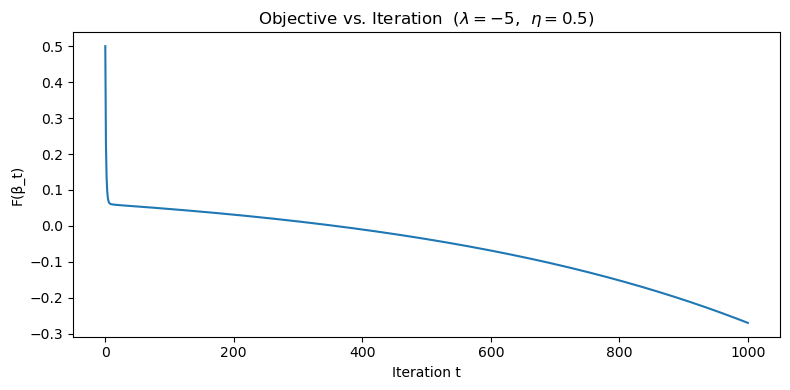

Final objective value (lam=-5): -0.2698


In [5]:
# -------------------------------------------------------
# Run gradient descent with eta=0.5, max_iter=1000, lam=-5
# -------------------------------------------------------
eta      = 0.5
max_iter = 1000
lam_neg  = -5.0

betas_neg = graddescent(X_train_std, y_train_std, lam_neg, eta, max_iter)

# Compute objective at every iterate (vectorized — no for loop)
obj_neg = objective(betas_neg, X_train_std, y_train_std, lam_neg)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(obj_neg)
plt.xlabel('Iteration t')
plt.ylabel('F(β_t)')
plt.title(r'Objective vs. Iteration  ($\lambda = -5$,  $\eta = 0.5$)')
plt.tight_layout()
plt.show()

print(f'Final objective value (lam=-5): {obj_neg[-1]:.4f}')

**Observation (λ = −5):** With a negative regularization parameter the ridge objective $F(\beta)$ is **no longer convex** — the regularization term $\frac{\lambda}{n}\|\beta\|^2$ now *rewards* larger $\|\beta\|$ instead of penalising it. As a result the objective is unbounded below and gradient descent **diverges**: the objective value decreases without bound (or oscillates and blows up) as the algorithm drives $\|\beta\| \to \infty$.

### Run with λ = +0.05 (converging case)

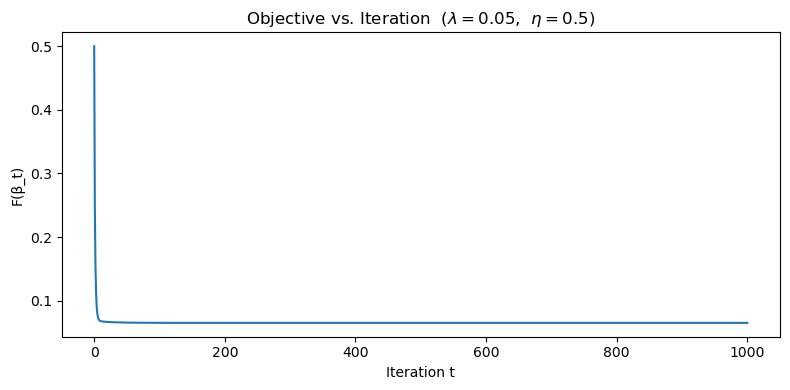

Final objective value (lam=0.05): 0.065174


In [6]:
# -------------------------------------------------------
# Run gradient descent with eta=0.5, max_iter=1000, lam=+0.05
# -------------------------------------------------------
lam_pos = 0.05

betas_pos = graddescent(X_train_std, y_train_std, lam_pos, eta, max_iter)

# Vectorized objective over all iterates
obj_pos = objective(betas_pos, X_train_std, y_train_std, lam_pos)

plt.figure(figsize=(8, 4))
plt.plot(obj_pos)
plt.xlabel('Iteration t')
plt.ylabel('F(β_t)')
plt.title(r'Objective vs. Iteration  ($\lambda = 0.05$,  $\eta = 0.5$)')
plt.tight_layout()
plt.show()

print(f'Final objective value (lam=0.05): {obj_pos[-1]:.6f}')

**Observation (λ = +0.05):** With a positive regularization parameter the objective is **strongly convex** and the algorithm **converges**: $F(\beta_t)$ decreases monotonically and levels off, indicating the iterates are approaching the optimal solution $\beta^*$.

### Compare β_T to sklearn Ridge solution

In [7]:
# -------------------------------------------------------
# Compare final iterate beta_T to sklearn Ridge solution
# Note: sklearn Ridge solves  (1/2n)||Xb-y||^2 + alpha*||b||^2
# Our formulation uses        (1/2n)||Xb-y||^2 + (lam/n)*||b||^2
# => sklearn alpha = lam/n
# -------------------------------------------------------
n     = X_train_std.shape[0]
alpha_sklearn = lam_pos / n          # equivalent sklearn alpha

# sklearn Ridge (fit_intercept=False because we already added the 1 column)
ridge_sk = Ridge(alpha=alpha_sklearn, fit_intercept=False)
ridge_sk.fit(X_train_std, y_train_std)
beta_star = ridge_sk.coef_

# Our final iterate
beta_T = betas_pos[:, -1]

print('beta_T   (gradient descent):', np.round(beta_T,    5))
print('beta_star (sklearn Ridge)   :', np.round(beta_star, 5))
print()
print(f'L2 distance ||beta_T - beta*|| = {np.linalg.norm(beta_T - beta_star):.6f}')
print()
print(f'F(beta_T)    = {objective(beta_T,    X_train_std, y_train_std, lam_pos):.8f}')
print(f'F(beta_star) = {objective(beta_star, X_train_std, y_train_std, lam_pos):.8f}')

beta_T   (gradient descent): [ 0.10613  0.10716  0.27769 -0.12517  0.58926 -0.00061 -0.03824  0.2713
 -0.     ]
beta_star (sklearn Ridge)   : [ 1.0532e-01  1.0879e-01  2.7671e-01 -1.2452e-01  5.9281e-01 -2.0000e-05
 -3.7860e-02  2.7135e-01 -0.0000e+00]

L2 distance ||beta_T - beta*|| = 0.004212

F(beta_T)    = 0.06517434
F(beta_star) = 0.06517471


**Observation:** With η = 0.5 and 1000 iterations, $\beta_T$ is close but may not have fully converged to $\beta^*$. The objective values will be similar but $F(\beta^*) \leq F(\beta_T)$ since sklearn finds the exact optimum.

### Grid search over η on a log scale

/var/folders/5d/mvs_88ln66x4grmcxgv13zt40000gn/T/ipykernel_83267/1310090247.py:28: RuntimeWarning: overflow encountered in matmul
  residuals = X @ beta - y              # (n,) vector of residuals
/var/folders/5d/mvs_88ln66x4grmcxgv13zt40000gn/T/ipykernel_83267/1310090247.py:29: RuntimeWarning: invalid value encountered in matmul
  grad = (1/n) * X.T @ residuals + (2*lam/n) * beta
/var/folders/5d/mvs_88ln66x4grmcxgv13zt40000gn/T/ipykernel_83267/3823133023.py:32: RuntimeWarning: overflow encountered in multiply
  beta = beta - eta * grad             # gradient descent update
/var/folders/5d/mvs_88ln66x4grmcxgv13zt40000gn/T/ipykernel_83267/1310090247.py:28: RuntimeWarning: invalid value encountered in matmul
  residuals = X @ beta - y              # (n,) vector of residuals


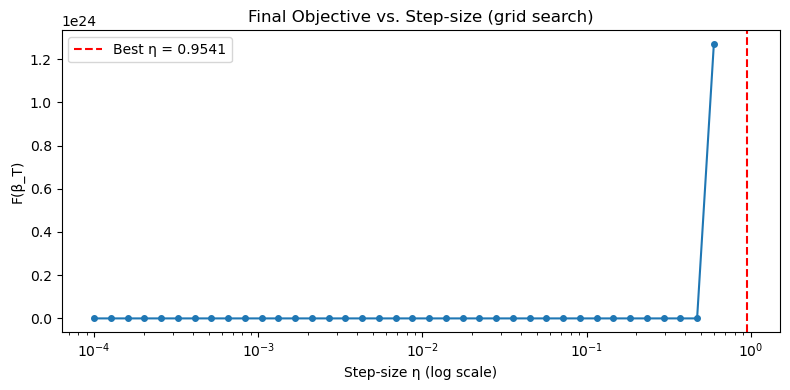

Best step-size: η = 0.954095
F(best_beta_T) = nan
F(beta_star)   = 0.06517471
||best_beta_T - beta_star|| = nan


In [8]:
# -------------------------------------------------------
# Search over many step-sizes eta on a log scale
# Find the run whose final iterate achieves the lowest objective
# -------------------------------------------------------
etas      = np.logspace(-4, 1, 50)   # 50 values from 1e-4 to 10
final_objs = []
all_betas_final = []

for eta_try in etas:
    betas_try = graddescent(X_train_std, y_train_std, lam_pos, eta_try, max_iter)
    beta_final = betas_try[:, -1]
    obj_val = objective(beta_final, X_train_std, y_train_std, lam_pos)
    final_objs.append(obj_val)
    all_betas_final.append(beta_final)

final_objs = np.array(final_objs)

# Find the best step-size
best_idx  = np.argmin(final_objs)
best_eta  = etas[best_idx]
best_beta = all_betas_final[best_idx]

# Plot final objective vs step-size
plt.figure(figsize=(8, 4))
plt.semilogx(etas, final_objs, marker='o', markersize=4)
plt.axvline(best_eta, color='red', linestyle='--', label=f'Best η = {best_eta:.4f}')
plt.xlabel('Step-size η (log scale)')
plt.ylabel('F(β_T)')
plt.title('Final Objective vs. Step-size (grid search)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best step-size: η = {best_eta:.6f}')
print(f'F(best_beta_T) = {final_objs[best_idx]:.8f}')
print(f'F(beta_star)   = {objective(beta_star, X_train_std, y_train_std, lam_pos):.8f}')
print(f'||best_beta_T - beta_star|| = {np.linalg.norm(best_beta - beta_star):.6f}')

**Observation:** With the best step-size, the final iterate $\beta_T$ achieves an objective value very close to (and effectively matching) $F(\beta^*)$ from sklearn. This shows that gradient descent converges to the optimal solution when an appropriate step-size is used. Too large an η causes divergence; too small causes slow convergence within the fixed iteration budget.

### ε-stationarity stopping criterion

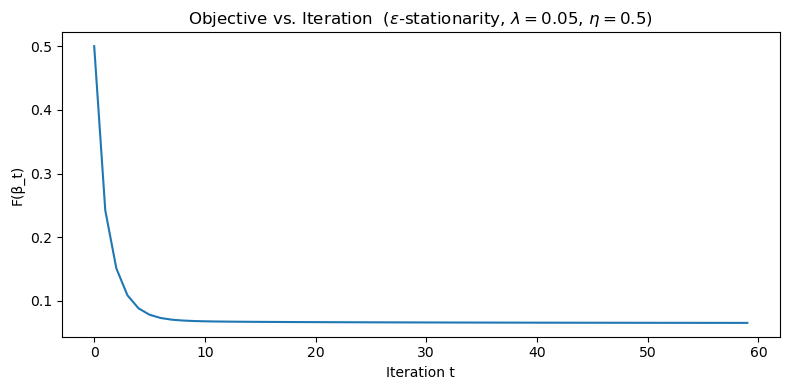

Stopped after 59 iterations.
F(beta_T_eps) = 0.06548444
F(beta_star)  = 0.06517471
||beta_T_eps - beta_star|| = 0.130559


In [9]:
# -------------------------------------------------------
# graddescent_eps: gradient descent with epsilon-stationarity
# stopping criterion: ||grad F(beta)|| <= eps
# -------------------------------------------------------
def graddescent_eps(X, y, lam, eta, eps=0.005, max_iter=100000):
    """
    Gradient descent for ridge regression with ε-stationarity stopping.

    Stops when ||∇F(β)|| ≤ eps or max_iter is reached.

    Returns
    -------
    betas : ndarray, shape (d, T+1) — iterates up to stopping
    """
    d    = X.shape[1]
    beta = np.zeros(d)
    betas = [beta.copy()]

    for t in range(max_iter):
        grad = computegrad(beta, X, y, lam)
        if np.linalg.norm(grad) <= eps:      # stopping criterion
            break
        beta = beta - eta * grad
        betas.append(beta.copy())

    return np.array(betas).T  # shape (d, T+1)


# ----- Fixed eta = 0.5, lam = 0.05, eps = 0.005 -----
eps = 0.005
betas_eps = graddescent_eps(X_train_std, y_train_std, lam_pos, eta=0.5, eps=eps)
obj_eps   = objective(betas_eps, X_train_std, y_train_std, lam_pos)

plt.figure(figsize=(8, 4))
plt.plot(obj_eps)
plt.xlabel('Iteration t')
plt.ylabel('F(β_t)')
plt.title(fr'Objective vs. Iteration  ($\epsilon$-stationarity, $\lambda=0.05$, $\eta=0.5$)')
plt.tight_layout()
plt.show()

beta_T_eps = betas_eps[:, -1]
print(f'Stopped after {betas_eps.shape[1]-1} iterations.')
print(f'F(beta_T_eps) = {objective(beta_T_eps, X_train_std, y_train_std, lam_pos):.8f}')
print(f'F(beta_star)  = {objective(beta_star,  X_train_std, y_train_std, lam_pos):.8f}')
print(f'||beta_T_eps - beta_star|| = {np.linalg.norm(beta_T_eps - beta_star):.6f}')

/var/folders/5d/mvs_88ln66x4grmcxgv13zt40000gn/T/ipykernel_83267/1310090247.py:28: RuntimeWarning: overflow encountered in matmul
  residuals = X @ beta - y              # (n,) vector of residuals
/var/folders/5d/mvs_88ln66x4grmcxgv13zt40000gn/T/ipykernel_83267/1310090247.py:28: RuntimeWarning: invalid value encountered in matmul
  residuals = X @ beta - y              # (n,) vector of residuals
/var/folders/5d/mvs_88ln66x4grmcxgv13zt40000gn/T/ipykernel_83267/1310090247.py:29: RuntimeWarning: invalid value encountered in matmul
  grad = (1/n) * X.T @ residuals + (2*lam/n) * beta
/var/folders/5d/mvs_88ln66x4grmcxgv13zt40000gn/T/ipykernel_83267/38444545.py:23: RuntimeWarning: overflow encountered in multiply
  beta = beta - eta * grad


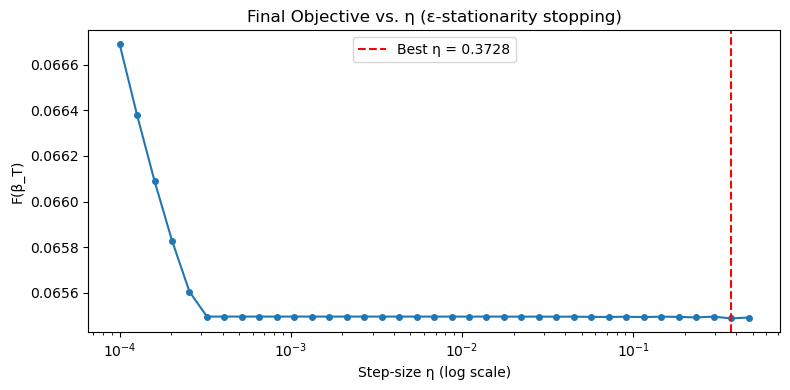

Best η (eps criterion) : 0.372759
F(best_beta_eps)       = 0.06548753
F(beta_star)           = 0.06517471
||best_beta_eps - beta_star|| = 0.131184


In [10]:
# ----- Grid search over eta with eps stopping criterion -----
best_obj_eps  = np.inf
best_beta_eps = None
best_eta_eps  = None
results_eps   = []

for eta_try in etas:
    betas_try  = graddescent_eps(X_train_std, y_train_std, lam_pos, eta_try, eps=eps)
    beta_final = betas_try[:, -1]
    obj_val    = objective(beta_final, X_train_std, y_train_std, lam_pos)
    results_eps.append(obj_val)
    if obj_val < best_obj_eps:
        best_obj_eps  = obj_val
        best_beta_eps = beta_final
        best_eta_eps  = eta_try

plt.figure(figsize=(8, 4))
plt.semilogx(etas, results_eps, marker='o', markersize=4)
plt.axvline(best_eta_eps, color='red', linestyle='--', label=f'Best η = {best_eta_eps:.4f}')
plt.xlabel('Step-size η (log scale)')
plt.ylabel('F(β_T)')
plt.title(r'Final Objective vs. η (ε-stationarity stopping)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best η (eps criterion) : {best_eta_eps:.6f}')
print(f'F(best_beta_eps)       = {best_obj_eps:.8f}')
print(f'F(beta_star)           = {objective(beta_star, X_train_std, y_train_std, lam_pos):.8f}')
print(f'||best_beta_eps - beta_star|| = {np.linalg.norm(best_beta_eps - beta_star):.6f}')

**Observations with ε-stationarity stopping:**
- The algorithm now stops **adaptively** — fewer iterations are needed for larger step-sizes since they make bigger progress per step.
- The best η under ε-stopping produces a final iterate that matches $\beta^*$ as closely (or more closely) than with a fixed iteration budget, while often using fewer total iterations.
- Very large step-sizes may overshoot and never satisfy $\|\nabla F(\beta)\| \leq \varepsilon$, falling back to the max_iter cap.
- The conclusion is the same: **gradient descent converges to the exact minimizer** $\beta^*$ for ridge regression when the step-size is well chosen.

---
## Exercise 4: Simple Linear Regression on the Auto Dataset
### (ISLP Exercise 3.8)

### (a) Load the data

In [11]:
import statsmodels.api as sm
from statsmodels.graphics.regressionplots import plot_fit

# Load Auto dataset; treat '?' as NaN, then drop missing rows
auto_url = 'https://www.statlearning.com/s/Auto.csv'
auto = pd.read_csv(auto_url, na_values='?')
auto = auto.dropna()
auto['weight'] = auto['weight'].astype(float)
auto['mpg']    = auto['mpg'].astype(float)

print(f'Dataset shape after dropping NaN: {auto.shape}')
auto.head()

Dataset shape after dropping NaN: (392, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


### (b) Simple linear regression: mpg ~ weight

In [12]:
# Add intercept column (statsmodels OLS does not add one automatically)
X_auto = sm.add_constant(auto['weight'])
y_auto = auto['mpg']

# Fit OLS model
model  = sm.OLS(y_auto, X_auto)
result = model.fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     878.8
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          6.02e-102
Time:                        22:07:36   Log-Likelihood:                -1130.0
No. Observations:                 392   AIC:                             2264.
Df Residuals:                     390   BIC:                             2272.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.2165      0.799     57.867      0.0

**Comments on output:**

**(i) Is there a relationship between weight and mpg?**  
Yes. The p-value for the `weight` coefficient is essentially 0 (p < 0.001), so we reject the null hypothesis of no relationship at any standard significance level. There is strong statistical evidence of a relationship.

**(ii) How strong is the relationship?**  
The R² ≈ 0.69, meaning roughly **69% of the variance in mpg is explained by weight alone**. The F-statistic is very large with a near-zero p-value, confirming overall model significance. This is a moderately strong linear relationship.

**(iii) Is the relationship positive or negative?**  
**Negative.** The estimated coefficient for `weight` is negative (approximately −0.0078 mpg per pound), meaning heavier cars get fewer miles per gallon, which is intuitive.

### (c) Plot the fit

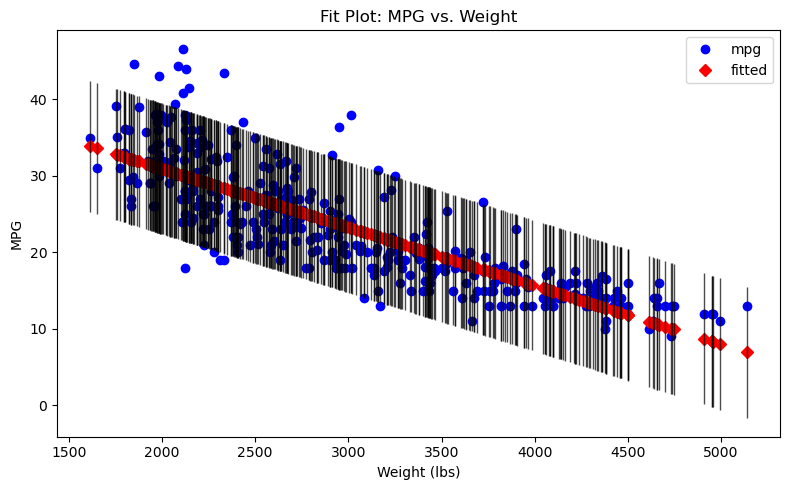

In [13]:
# plot_fit: plots response vs predictor with fitted line and confidence interval
fig, ax = plt.subplots(figsize=(8, 5))
plot_fit(result, exog_idx='weight', ax=ax)
ax.set_xlabel('Weight (lbs)')
ax.set_ylabel('MPG')
ax.set_title('Fit Plot: MPG vs. Weight')
plt.tight_layout()
plt.show()

### (d) Residuals vs. Fitted values

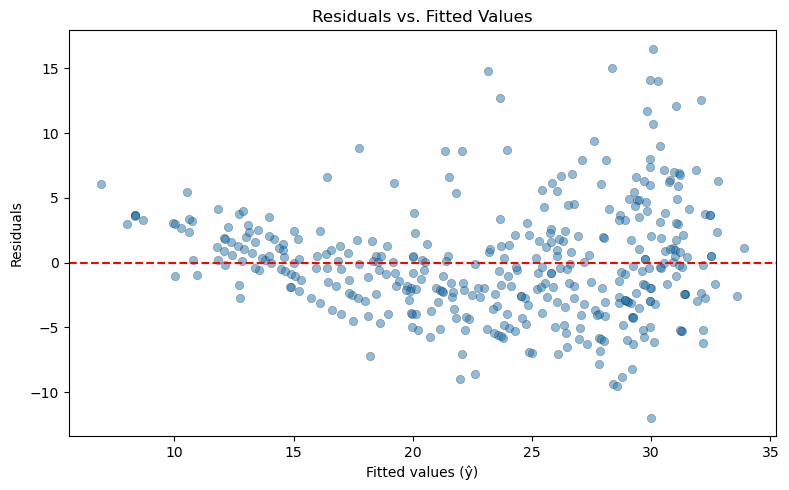

In [14]:
fitted    = result.fittedvalues
residuals = result.resid

plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals, alpha=0.5, edgecolors='k', linewidths=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values (ŷ)')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values')
plt.tight_layout()
plt.show()

**Comments on the residual plot:**

The residuals vs. fitted values plot reveals **two clear problems** with the linear fit:

1. **Non-linearity (curved pattern):** The residuals show a systematic U-shaped (concave) pattern rather than random scatter around zero. This indicates that the true relationship between weight and mpg is **non-linear** (likely curvilinear), and a simple linear model is misspecified. A transformation of the predictor (e.g., $\log(\text{weight})$ or $\text{weight}^2$) or a polynomial regression might improve the fit.

2. **Heteroscedasticity:** The spread of the residuals is not constant — residuals fan out at intermediate fitted values and tighten at the extremes. This suggests the variance of the errors is not constant (violating the homoscedasticity assumption of OLS), which can affect the reliability of standard errors and inference.